In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the development dataset
df = pd.read_csv("data/train-test.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [4]:
# Create a compact summary for each column
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique()
})

summary

,dtype,missing_count,missing_percent,unique_values
load_id,object,0,0.00,48000
pickup,object,0,0.00,64
delivery,object,0,0.00,64
pickup_lat,float64,0,0.00,64
pickup_lon,float64,0,0.00,63
delivery_lat,float64,0,0.00,64
delivery_lon,float64,0,0.00,63
distance,float64,0,0.00,21204
equipment,object,0,0.00,3
weight,float64,300,0.62,23678


Target: posted_rate
count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

Median: 2030.76
Skewness: 1.9023948792201815


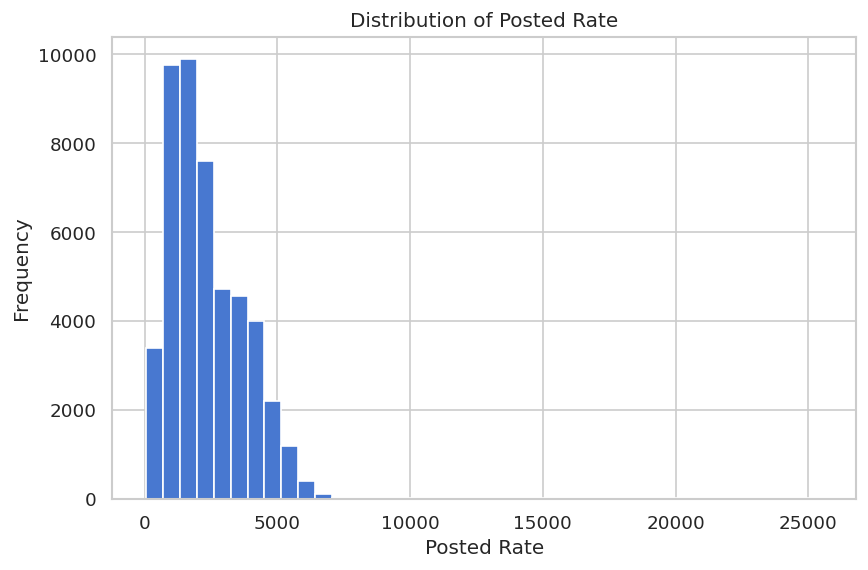

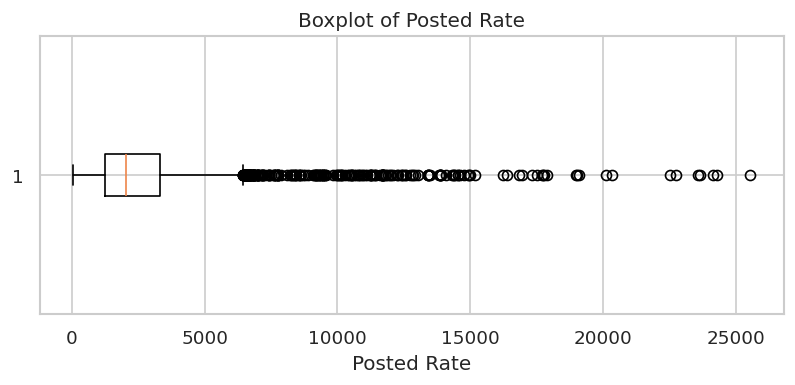

In [5]:
# Summary statistics for the target
print("Target: posted_rate")
print(df["posted_rate"].describe())

print("\nMedian:", df["posted_rate"].median())
print("Skewness:", df["posted_rate"].skew())

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df["posted_rate"], bins=40)
plt.title("Distribution of Posted Rate")
plt.xlabel("Posted Rate")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(8, 3))
plt.boxplot(df["posted_rate"], vert=False)
plt.title("Boxplot of Posted Rate")
plt.xlabel("Posted Rate")
plt.show()

In [6]:
# Create a temporary EDA copy
eda_df = df.copy()

# Diagnostic metric for EDA only
eda_df["rate_per_mile"] = eda_df["posted_rate"] / eda_df["distance"]

# Columns we want to inspect
cols_to_show = [
    "load_id",
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate",
    "rate_per_mile"
]

print("10 Highest Posted Rates")
display(
    eda_df[cols_to_show]
    .sort_values("posted_rate", ascending=False)
    .head(10)
)

print("\n10 Lowest Posted Rates")
display(
    eda_df[cols_to_show]
    .sort_values("posted_rate", ascending=True)
    .head(10)
)

10 Highest Posted Rates


,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate,rate_per_mile
12184,TR-012185,Bakersfield,Hartford,2829.8,Dry Van,33153.0,1.16556,1.83188,25533.00,9.022899
37764,TR-037765,Phoenix,Syracuse,2810.9,Dry Van,33674.0,1.04877,2.16284,24294.98,8.643132
1466,TR-001467,Los Angeles,Syracuse,2786.0,Reefer,30322.0,0.98678,1.85370,24140.21,8.664828
17371,TR-017372,Reno,Philadelphia,2777.6,Reefer,33158.0,1.15070,2.15601,23662.71,8.519121
26235,TR-026236,Charleston,Phoenix,2552.5,Dry Van,25665.0,1.20224,1.81289,23580.42,9.238167
28219,TR-028220,Tucson,Raleigh,2423.3,Dry Van,30972.0,1.32894,1.97112,22755.66,9.390360
3353,TR-003354,Phoenix,Charleston,2527.9,Reefer,36840.0,1.03241,2.07342,22534.65,8.914376
40171,TR-040172,Montgomery,Fresno,2283.4,Dry Van,32447.0,0.98502,1.93645,20361.89,8.917356
40096,TR-040097,Baltimore,Oklahoma City,1760.3,Reefer,29521.0,1.00464,2.28753,20132.37,11.436897
47298,TR-047299,Boston,Bakersfield,2979.1,Reefer,30585.0,0.86501,2.09472,19110.30,6.414790



10 Lowest Posted Rates


,load_id,pickup,delivery,distance,equipment,weight,market_index,quote_signal,posted_rate,rate_per_mile
5961,TR-005962,Grand Rapids,Green Bay,105.5,Dry Van,24598.0,1.02929,2.41080,57.22,0.542370
30705,TR-030706,Hartford,New York,114.4,Dry Van,25901.0,1.22535,1.49168,59.68,0.521678
14990,TR-014991,Los Angeles,Phoenix,93.9,Reefer,32284.0,1.12290,1.06179,63.36,0.674760
872,TR-000873,Cincinnati,Lexington,144.0,Dry Van,13535.0,0.76351,2.35079,67.80,0.470833
4674,TR-004675,Hartford,Baltimore,149.3,Reefer,27506.0,1.03157,2.76994,75.19,0.503617
9137,TR-009138,Fort Wayne,Toledo,105.0,Reefer,35124.0,1.09168,3.00438,76.54,0.728952
34343,TR-034344,Louisville,Cincinnati,70.0,Dry Van,35673.0,0.94554,2.13051,82.38,1.176857
10959,TR-010960,Lubbock,San Antonio,122.6,Reefer,42648.0,1.05748,3.30032,94.72,0.772594
18954,TR-018955,Cincinnati,St. Louis,228.7,Dry Van,25262.0,1.25876,1.70432,101.63,0.444381
11236,TR-011237,Columbia,Lexington,228.3,Dry Van,22221.0,1.18576,2.48670,103.15,0.451818


Correlation with posted_rate:


,correlation
posted_rate,1.000000
distance,0.908519
weight,0.034840
market_index,0.034165
quote_signal,-0.039858
pickup_lat,-0.090873
delivery_lat,-0.091970
pickup_lon,-0.255058
delivery_lon,-0.257086


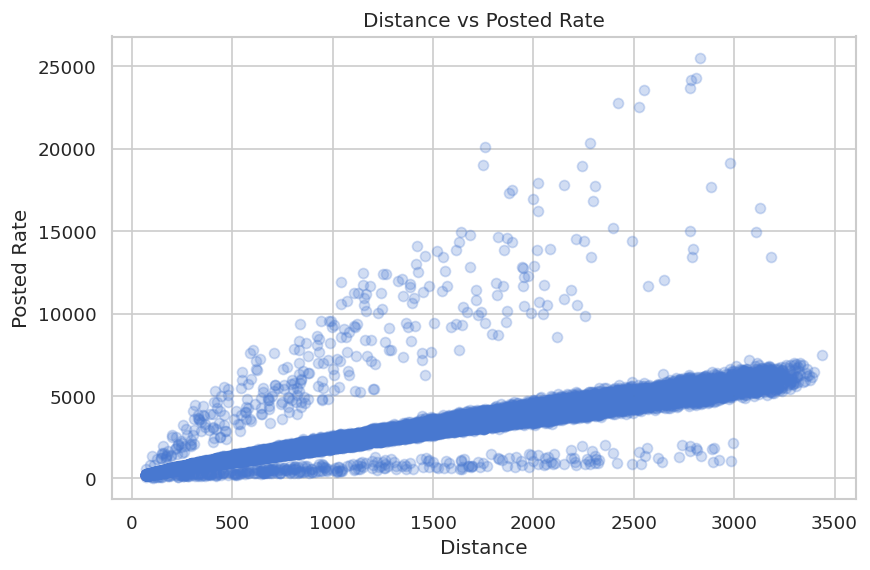

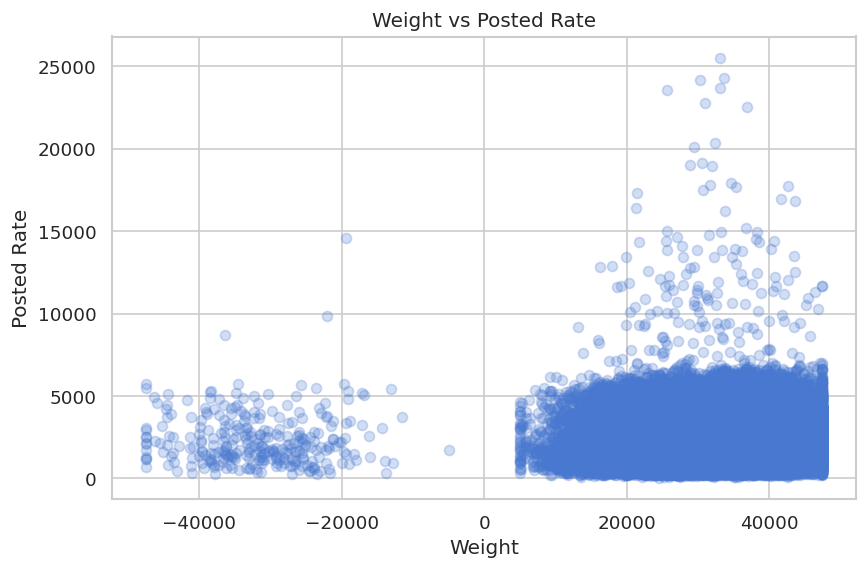

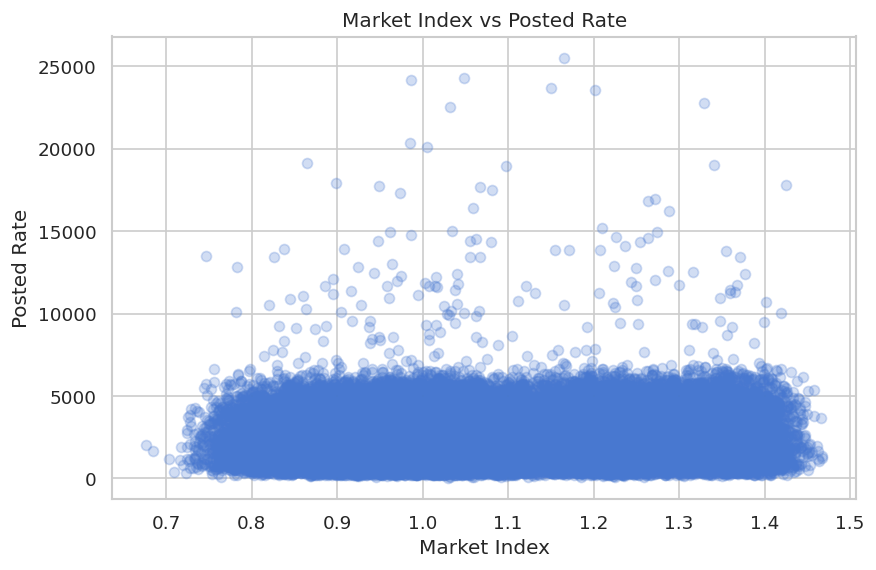

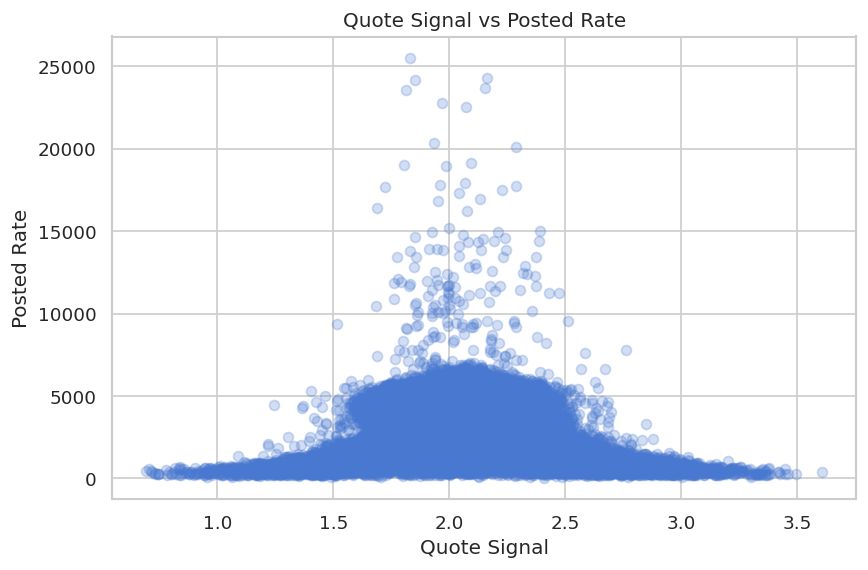

In [7]:
# Correlation of numerical features with the target
numeric_corr = (
    df.select_dtypes(include=np.number)
      .corr()["posted_rate"]
      .sort_values(ascending=False)
)

print("Correlation with posted_rate:")
display(numeric_corr.to_frame(name="correlation"))


# Distance vs Posted Rate
plt.figure(figsize=(8, 5))
plt.scatter(df["distance"], df["posted_rate"], alpha=0.25)
plt.title("Distance vs Posted Rate")
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.show()


# Weight vs Posted Rate
plt.figure(figsize=(8, 5))
plt.scatter(df["weight"], df["posted_rate"], alpha=0.25)
plt.title("Weight vs Posted Rate")
plt.xlabel("Weight")
plt.ylabel("Posted Rate")
plt.show()


# Market Index vs Posted Rate
plt.figure(figsize=(8, 5))
plt.scatter(df["market_index"], df["posted_rate"], alpha=0.25)
plt.title("Market Index vs Posted Rate")
plt.xlabel("Market Index")
plt.ylabel("Posted Rate")
plt.show()


# Quote Signal vs Posted Rate
plt.figure(figsize=(8, 5))
plt.scatter(df["quote_signal"], df["posted_rate"], alpha=0.25)
plt.title("Quote Signal vs Posted Rate")
plt.xlabel("Quote Signal")
plt.ylabel("Posted Rate")
plt.show()

In [8]:
# Create a temporary copy for weight investigation
weight_check = df.copy()
weight_check["date"] = pd.to_datetime(weight_check["date"])

# Basic counts
negative_weights = weight_check["weight"] < 0
zero_weights = weight_check["weight"] == 0
missing_weights = weight_check["weight"].isna()
positive_weights = weight_check["weight"] > 0

print("WEIGHT DATA QUALITY SUMMARY")
print("-" * 35)
print(f"Total rows:             {len(weight_check):,}")
print(f"Missing weights:        {missing_weights.sum():,}")
print(f"Zero weights:           {zero_weights.sum():,}")
print(f"Negative weights:       {negative_weights.sum():,}")
print(f"Positive weights:       {positive_weights.sum():,}")

print("\nOverall weight range:")
print("Minimum:", weight_check["weight"].min())
print("Maximum:", weight_check["weight"].max())


# Inspect negative-weight rows
cols = [
    "load_id",
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "market_index",
    "quote_signal",
    "posted_rate"
]

print("\nSample of Negative Weight Rows")
display(
    weight_check.loc[negative_weights, cols]
    .sort_values("weight")
    .head(15)
)


# Compare absolute negative weights with valid positive weights
negative_abs = weight_check.loc[negative_weights, "weight"].abs()
positive = weight_check.loc[positive_weights, "weight"]

comparison = pd.DataFrame({
    "Positive Weights": positive.describe(),
    "Absolute Negative Weights": negative_abs.describe()
})

print("\nDistribution Comparison")
display(comparison.round(2))


# Check equipment pattern
print("\nNegative Weights by Equipment")
negative_equipment = (
    weight_check.loc[negative_weights, "equipment"]
    .value_counts()
    .to_frame("negative_count")
)

negative_equipment["negative_percent"] = (
    negative_equipment["negative_count"] /
    negative_weights.sum() * 100
).round(2)

display(negative_equipment)


# Check whether negative values appear during specific months
print("\nNegative Weights by Month")
negative_by_month = (
    weight_check.loc[negative_weights]
    .assign(month=weight_check.loc[negative_weights, "date"].dt.to_period("M"))
    ["month"]
    .value_counts()
    .sort_index()
    .to_frame("negative_count")
)

display(negative_by_month)


# Most common pickup/delivery locations among negative-weight rows
print("\nTop Pickups with Negative Weights")
display(
    weight_check.loc[negative_weights, "pickup"]
    .value_counts()
    .head(10)
    .to_frame("count")
)

print("\nTop Deliveries with Negative Weights")
display(
    weight_check.loc[negative_weights, "delivery"]
    .value_counts()
    .head(10)
    .to_frame("count")
)

WEIGHT DATA QUALITY SUMMARY
-----------------------------------
Total rows:             48,000
Missing weights:        300
Zero weights:           0
Negative weights:       292
Positive weights:       47,408

Overall weight range:
Minimum: -47500.0
Maximum: 47500.0

Sample of Negative Weight Rows


,load_id,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate
5236,TR-005237,Oklahoma City,Baton Rouge,459.1,Reefer,-47500.0,2025-02-02,0.84248,2.64037,1207.21
12591,TR-012592,Los Angeles,Richmond,2749.0,Reefer,-47500.0,2025-03-21,1.13917,2.10986,5741.43
28877,TR-028878,Nashville,Fort Wayne,518.5,Reefer,-47500.0,2025-07-01,1.24931,1.57956,1328.65
13620,TR-013621,Fort Wayne,Philadelphia,789.2,Dry Van,-47500.0,2025-03-28,1.18692,2.17532,1704.51
18064,TR-018065,Green Bay,Kansas City,475.4,Flatbed,-47500.0,2025-04-24,1.38826,1.61000,1203.67
18488,TR-018489,Syracuse,Phoenix,2760.8,Flatbed,-47500.0,2025-04-27,1.16860,2.14330,5478.31
16823,TR-016824,Madison,Green Bay,273.1,Dry Van,-47500.0,2025-04-16,1.29884,1.67887,676.06
34282,TR-034283,Bakersfield,Oklahoma City,1241.0,Dry Van,-47500.0,2025-08-04,0.94466,2.23305,2485.16
20576,TR-020577,Montgomery,Amarillo,1265.6,Flatbed,-47500.0,2025-05-10,1.29040,1.79297,2919.39
22422,TR-022423,Amarillo,San Francisco,1185.8,Dry Van,-47500.0,2025-05-22,1.37498,2.03384,2539.75



Distribution Comparison


,Positive Weights,Absolute Negative Weights
count,47408.00,292.00
mean,31415.36,31724.20
std,7994.90,8262.54
min,5000.00,5000.00
25%,25922.00,25928.50
50%,31493.50,31821.50
75%,37063.00,37284.25
max,47500.00,47500.00



Negative Weights by Equipment


...

,negative_count
month,
2025-01,31
2025-02,30
2025-03,40
2025-04,25
2025-05,40
2025-06,30
2025-07,22
2025-08,15
2025-09,26



Top Pickups with Negative Weights


,count
pickup,
Cincinnati,11
Columbia,10
Milwaukee,10
Fort Wayne,10
Kansas City,9
Richmond,8
Baton Rouge,8
Mobile,8
Atlanta,8



Top Deliveries with Negative Weights


,count
delivery,
Baton Rouge,10
Phoenix,10
Memphis,10
Hartford,10
Mobile,9
Buffalo,9
Kansas City,8
Oklahoma City,8
Richmond,8


In [9]:
# Fix negative weight values by converting them to absolute values
df.loc[df["weight"] < 0, "weight"] = df.loc[df["weight"] < 0, "weight"].abs()

# Verify the correction
print("Negative weights remaining:", (df["weight"] < 0).sum())
print("Missing weights remaining:", df["weight"].isna().sum())
print("Minimum valid weight:", df["weight"].min())

Negative weights remaining: 0
Missing weights remaining: 300
Minimum valid weight: 5000.0


In [10]:
# Convert date temporarily for missing-value analysis
df["date"] = pd.to_datetime(df["date"])

# Missing masks
missing_weight = df["weight"].isna()
missing_market = df["market_index"].isna()

print("MISSING VALUE SUMMARY")
print("-" * 35)
print(f"Missing weight rows:        {missing_weight.sum():,}")
print(f"Missing market_index rows:  {missing_market.sum():,}")
print(f"Rows missing both:          {(missing_weight & missing_market).sum():,}")


# ---------------------------------------------------
# 1. Sample rows with missing weight
# ---------------------------------------------------
print("\nSample Rows with Missing Weight")

weight_cols = [
    "load_id",
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "market_index",
    "quote_signal",
    "posted_rate"
]

display(
    df.loc[missing_weight, weight_cols].head(15)
)


# ---------------------------------------------------
# 2. Sample rows with missing market_index
# ---------------------------------------------------
print("\nSample Rows with Missing Market Index")

market_cols = [
    "load_id",
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "date",
    "market_index",
    "quote_signal",
    "posted_rate"
]

display(
    df.loc[missing_market, market_cols].head(15)
)


# ---------------------------------------------------
# 3. Missing values by month
# ---------------------------------------------------
df["month"] = df["date"].dt.to_period("M")

print("\nMissing Weight by Month")
display(
    df.loc[missing_weight, "month"]
      .value_counts()
      .sort_index()
      .to_frame("missing_weight_count")
)

print("\nMissing Market Index by Month")
display(
    df.loc[missing_market, "month"]
      .value_counts()
      .sort_index()
      .to_frame("missing_market_count")
)


# ---------------------------------------------------
# 4. Missing values by equipment type
# ---------------------------------------------------
print("\nMissing Weight by Equipment")
display(
    df.loc[missing_weight, "equipment"]
      .value_counts()
      .to_frame("missing_weight_count")
)

print("\nMissing Market Index by Equipment")
display(
    df.loc[missing_market, "equipment"]
      .value_counts()
      .to_frame("missing_market_count")
)


# ---------------------------------------------------
# 5. Compare missing vs non-missing rows
# ---------------------------------------------------
comparison_weight = pd.DataFrame({
    "Missing Weight Rows": df.loc[missing_weight, [
        "distance", "market_index", "quote_signal", "posted_rate"
    ]].mean(),

    "Non-Missing Weight Rows": df.loc[~missing_weight, [
        "distance", "market_index", "quote_signal", "posted_rate"
    ]].mean()
})

print("\nAverage Feature Comparison: Missing vs Non-Missing Weight")
display(comparison_weight.round(2))


comparison_market = pd.DataFrame({
    "Missing Market Rows": df.loc[missing_market, [
        "distance", "weight", "quote_signal", "posted_rate"
    ]].mean(),

    "Non-Missing Market Rows": df.loc[~missing_market, [
        "distance", "weight", "quote_signal", "posted_rate"
    ]].mean()
})

print("\nAverage Feature Comparison: Missing vs Non-Missing Market Index")
display(comparison_market.round(2))


# ---------------------------------------------------
# 6. Most common routes with missing values
# ---------------------------------------------------
print("\nTop Routes with Missing Weight")
display(
    df.loc[missing_weight]
      .groupby(["pickup", "delivery"])
      .size()
      .sort_values(ascending=False)
      .head(10)
      .to_frame("count")
)

print("\nTop Routes with Missing Market Index")
display(
    df.loc[missing_market]
      .groupby(["pickup", "delivery"])
      .size()
      .sort_values(ascending=False)
      .head(10)
      .to_frame("count")
)

MISSING VALUE SUMMARY
-----------------------------------
Missing weight rows:        300
Missing market_index rows:  374
Rows missing both:          1

Sample Rows with Missing Weight


,load_id,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate
323,TR-000324,Richmond,San Francisco,2848.8,Reefer,NaN,2025-01-03,0.91370,1.92679,5430.07
648,TR-000649,Tulsa,Mobile,467.0,Reefer,NaN,2025-01-05,0.77536,2.48162,1178.03
694,TR-000695,Los Angeles,Fresno,432.6,Reefer,NaN,2025-01-05,0.84069,2.37036,1022.13
732,TR-000733,El Paso,Hartford,2497.6,Reefer,NaN,2025-01-05,0.79026,2.01004,4991.60
911,TR-000912,Washington,Kansas City,887.8,Dry Van,NaN,2025-01-06,0.81120,1.85853,1643.25
942,TR-000943,Jacksonville,Corpus Christi,833.9,Dry Van,NaN,2025-01-06,0.79617,1.90050,1602.03
963,TR-000964,Greensboro,Madison,640.8,Reefer,NaN,2025-01-07,0.89852,2.30231,1466.95
1009,TR-001010,Richmond,Savannah,550.2,Dry Van,NaN,2025-01-07,0.89645,2.10347,1161.37
1021,TR-001022,Albuquerque,Reno,678.8,Dry Van,NaN,2025-01-07,0.86853,1.91635,1318.04
1058,TR-001059,Charleston,Indianapolis,714.8,Dry Van,NaN,2025-01-07,0.85299,1.97105,1431.30



Sample Rows with Missing Market Index


,load_id,pickup,delivery,distance,equipment,weight,date,market_index,quote_signal,posted_rate
116,TR-000117,Memphis,Fort Wayne,533.8,Reefer,30570.0,2025-01-01,NaN,2.37177,1271.10
226,TR-000227,Tampa,Hartford,1342.7,Reefer,26397.0,2025-01-02,NaN,2.01837,2743.13
311,TR-000312,Los Angeles,New York,2935.7,Flatbed,32807.0,2025-01-02,NaN,1.91236,5568.57
511,TR-000512,Grand Rapids,Amarillo,1420.7,Reefer,19360.0,2025-01-04,NaN,1.94596,2786.63
531,TR-000532,Richmond,San Antonio,1624.7,Reefer,39452.0,2025-01-04,NaN,2.04970,3295.80
629,TR-000630,Birmingham,Fort Wayne,648.1,Dry Van,23236.0,2025-01-05,NaN,1.93237,1256.20
644,TR-000645,Lubbock,Milwaukee,1089.3,Dry Van,40473.0,2025-01-05,NaN,2.04466,2171.37
905,TR-000906,Fort Wayne,Toledo,80.0,Reefer,25930.0,2025-01-06,NaN,2.92545,231.54
1012,TR-001013,Chattanooga,Lubbock,978.6,Reefer,26383.0,2025-01-07,NaN,2.31501,2236.76
1274,TR-001275,Little Rock,Jacksonville,573.4,Dry Van,23277.0,2025-01-08,NaN,2.06009,1186.43



Missing Weight by Month


...

,Missing Market Rows,Non-Missing Market Rows
distance,1164.75,1135.63
weight,30394.95,31425.31
quote_signal,2.07,2.06
posted_rate,2392.12,2373.84



Top Routes with Missing Weight


,,count
pickup,delivery,
Boston,Oklahoma City,2
Grand Rapids,Mobile,2
Tulsa,Shreveport,2
Atlanta,Hartford,2
Raleigh,Boston,2
Lexington,Buffalo,2
Lubbock,Columbia,2
Bakersfield,Columbia,2
Green Bay,San Antonio,2



Top Routes with Missing Market Index


count
pickup      delivery            
Buffalo     San Francisco      3
Mobile      Bakersfield        2
Savannah    Phoenix            2
Montgomery  San Antonio        2
Harrisburg  Fort Wayne         2
Nashville   Greensboro         2
            New York           2
Richmond    San Antonio        2
Bakersfield New York           2
New York    Hartford           2

In [11]:
# Remove the temporary month column created during EDA
if "month" in df.columns:
    df = df.drop(columns="month")

# Define the chronological split
train_df = df[df["date"] < "2025-09-01"].copy()
val_df = df[df["date"] >= "2025-09-01"].copy()

# Check the split
print("Training set:")
print("Rows:", len(train_df))
print("Date range:", train_df["date"].min(), "to", train_df["date"].max())

print("\nValidation set:")
print("Rows:", len(val_df))
print("Date range:", val_df["date"].min(), "to", val_df["date"].max())

print("\nSplit percentages:")
print(f"Train: {len(train_df) / len(df) * 100:.2f}%")
print(f"Validation: {len(val_df) / len(df) * 100:.2f}%")

Training set:
Rows: 38477
Date range: 2025-01-01 00:00:00 to 2025-08-31 00:00:00

Validation set:
Rows: 9523
Date range: 2025-09-01 00:00:00 to 2025-10-31 00:00:00

Split percentages:
Train: 80.16%
Validation: 19.84%


In [12]:
# Fixed reference date for consistent time features
REFERENCE_DATE = pd.Timestamp("2025-01-01")


def create_date_features(data):
    data = data.copy()

    # Make sure date is in datetime format
    data["date"] = pd.to_datetime(data["date"])

    # Calendar features
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day
    data["day_of_week"] = data["date"].dt.dayofweek
    data["week_of_year"] = data["date"].dt.isocalendar().week.astype(int)

    # Weekend indicator: Saturday = 5, Sunday = 6
    data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

    # Continuous time feature
    data["days_since_start"] = (
        data["date"] - REFERENCE_DATE
    ).dt.days

    return data


# Apply the same feature engineering to both sets
train_df = create_date_features(train_df)
val_df = create_date_features(val_df)


# Verify the new features
date_features = [
    "date",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "days_since_start"
]

print("Training date features:")
display(train_df[date_features].head())

print("\nValidation date features:")
display(val_df[date_features].head())

print("\nDays since start ranges:")
print(
    "Train:",
    train_df["days_since_start"].min(),
    "to",
    train_df["days_since_start"].max()
)

print(
    "Validation:",
    val_df["days_since_start"].min(),
    "to",
    val_df["days_since_start"].max()
)

Training date features:


,date,month,day,day_of_week,week_of_year,is_weekend,days_since_start
0,2025-01-01,1,1,2,1,0,0
1,2025-01-01,1,1,2,1,0,0
2,2025-01-01,1,1,2,1,0,0
3,2025-01-01,1,1,2,1,0,0
4,2025-01-01,1,1,2,1,0,0



Validation date features:


,date,month,day,day_of_week,week_of_year,is_weekend,days_since_start
38477,2025-09-01,9,1,0,36,0,243
38478,2025-09-01,9,1,0,36,0,243
38479,2025-09-01,9,1,0,36,0,243
38480,2025-09-01,9,1,0,36,0,243
38481,2025-09-01,9,1,0,36,0,243



Days since start ranges:
Train: 0 to 242
Validation: 243 to 303


In [13]:
def create_route_feature(data):
    data = data.copy()

    data["route"] = (
        data["pickup"].astype(str)
        + " -> "
        + data["delivery"].astype(str)
    )

    return data


# Apply to both training and validation sets
train_df = create_route_feature(train_df)
val_df = create_route_feature(val_df)


# Check the new feature
print("Sample routes:")
display(
    train_df[
        ["pickup", "delivery", "route"]
    ].head(10)
)

print("\nUnique routes:")
print("Train:", train_df["route"].nunique())
print("Validation:", val_df["route"].nunique())

Sample routes:


,pickup,delivery,route
0,Richmond,Baltimore,Richmond -> Baltimore
1,Richmond,Philadelphia,Richmond -> Philadelphia
2,Philadelphia,Green Bay,Philadelphia -> Green Bay
3,Hartford,Atlanta,Hartford -> Atlanta
4,Dallas,Nashville,Dallas -> Nashville
5,Phoenix,Corpus Christi,Phoenix -> Corpus Christi
6,Fresno,San Antonio,Fresno -> San Antonio
7,San Francisco,Kansas City,San Francisco -> Kansas City
8,Bakersfield,Montgomery,Bakersfield -> Montgomery
9,Albuquerque,Phoenix,Albuquerque -> Phoenix



Unique routes:
Train: 3999
Validation: 3337


In [14]:
categorical_cols = ["pickup", "delivery", "equipment", "route"]

for col in categorical_cols:
    train_values = set(train_df[col].dropna().unique())
    val_values = set(val_df[col].dropna().unique())

    unseen_values = val_values - train_values

    unseen_rows = val_df[col].isin(unseen_values)

    print("=" * 60)
    print(f"Column: {col}")
    print(f"Train unique values: {len(train_values)}")
    print(f"Validation unique values: {len(val_values)}")
    print(f"Unseen unique values: {len(unseen_values)}")

    if len(val_values) > 0:
        print(
            f"Unseen category percentage: "
            f"{len(unseen_values) / len(val_values) * 100:.2f}%"
        )

    print(f"Validation rows affected: {unseen_rows.sum():,}")
    print(
        f"Percentage of validation rows affected: "
        f"{unseen_rows.mean() * 100:.2f}%"
    )

    if len(unseen_values) > 0:
        print("\nExamples of unseen values:")
        print(list(unseen_values)[:10])

    print()

Column: pickup
Train unique values: 64
Validation unique values: 64
Unseen unique values: 0
Unseen category percentage: 0.00%
Validation rows affected: 0
Percentage of validation rows affected: 0.00%

Column: delivery
Train unique values: 64
Validation unique values: 64
Unseen unique values: 0
Unseen category percentage: 0.00%
Validation rows affected: 0
Percentage of validation rows affected: 0.00%

Column: equipment
Train unique values: 3
Validation unique values: 3
Unseen unique values: 0
Unseen category percentage: 0.00%
Validation rows affected: 0
Percentage of validation rows affected: 0.00%

Column: route
Train unique values: 3999
Validation unique values: 3337
Unseen unique values: 15
Unseen category percentage: 0.45%
Validation rows affected: 21
Percentage of validation rows affected: 0.22%

Examples of unseen values:
['Providence -> Savannah', 'Madison -> St. Louis', 'Savannah -> Indianapolis', 'Las Vegas -> Birmingham', 'Baltimore -> Las Vegas', 'Albuquerque -> Birmingham', 

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# ---------------------------------------------------
# 1. Define target and features
# ---------------------------------------------------

target = "posted_rate"

categorical_features = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

numeric_features = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "days_since_start"
]


# ---------------------------------------------------
# 2. Create X and y
# ---------------------------------------------------

X_train = train_df[categorical_features + numeric_features].copy()
y_train = train_df[target].copy()

X_val = val_df[categorical_features + numeric_features].copy()
y_val = val_df[target].copy()


# ---------------------------------------------------
# 3. Ridge numeric preprocessing
# Median imputation + scaling
# ---------------------------------------------------

ridge_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# ---------------------------------------------------
# 4. XGBoost numeric preprocessing
# Median imputation only
# ---------------------------------------------------

xgb_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])


# ---------------------------------------------------
# 5. Categorical preprocessing
# ---------------------------------------------------

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])


# ---------------------------------------------------
# 6. Ridge preprocessor
# ---------------------------------------------------

ridge_preprocessor = ColumnTransformer([
    ("numeric", ridge_numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


# ---------------------------------------------------
# 7. XGBoost preprocessor
# ---------------------------------------------------

xgb_preprocessor = ColumnTransformer([
    ("numeric", xgb_numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])


# ---------------------------------------------------
# 8. Verify our datasets
# ---------------------------------------------------

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

print("\nCategorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

print("\nMissing values in X_train:")
display(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nMissing values in X_val:")
display(X_val.isnull().sum()[X_val.isnull().sum() > 0])

X_train shape: (38477, 18)
X_val shape: (9523, 18)

y_train shape: (38477,)
y_val shape: (9523,)

Categorical features: 4
Numeric features: 14

Missing values in X_train:


,0
weight,235
market_index,301



Missing values in X_val:


,0
weight,65
market_index,73


In [16]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone


# Alpha values to test
alpha_values = [0.1, 1, 10]


# Expanding time-based validation folds
folds = [
    {
        "name": "June",
        "train_end": "2025-06-01",
        "val_start": "2025-06-01",
        "val_end": "2025-07-01"
    },
    {
        "name": "July",
        "train_end": "2025-07-01",
        "val_start": "2025-07-01",
        "val_end": "2025-08-01"
    },
    {
        "name": "August",
        "train_end": "2025-08-01",
        "val_start": "2025-08-01",
        "val_end": "2025-09-01"
    }
]


results = []


for alpha in alpha_values:

    for fold in folds:

        # Expanding training period
        fold_train = train_df[
            train_df["date"] < fold["train_end"]
        ]

        # Validation month
        fold_val = train_df[
            (train_df["date"] >= fold["val_start"]) &
            (train_df["date"] < fold["val_end"])
        ]


        # Features and target
        X_fold_train = fold_train[
            categorical_features + numeric_features
        ]

        y_fold_train = fold_train[target]

        X_fold_val = fold_val[
            categorical_features + numeric_features
        ]

        y_fold_val = fold_val[target]


        # Ridge pipeline
        ridge_pipeline = Pipeline([
            ("preprocessor", clone(ridge_preprocessor)),
            ("model", Ridge(alpha=alpha))
        ])


        # Train
        ridge_pipeline.fit(X_fold_train, y_fold_train)


        # Predict
        predictions = ridge_pipeline.predict(X_fold_val)


        # Metrics
        mae = mean_absolute_error(
            y_fold_val,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                predictions
            )
        )

        r2 = r2_score(
            y_fold_val,
            predictions
        )


        results.append({
            "alpha": alpha,
            "validation_month": fold["name"],
            "train_rows": len(fold_train),
            "validation_rows": len(fold_val),
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


# Convert results to DataFrame
ridge_cv_results = pd.DataFrame(results)


print("RIDGE CROSS-VALIDATION RESULTS")
display(
    ridge_cv_results.round(3)
)


# Average performance for each alpha
ridge_cv_summary = (
    ridge_cv_results
    .groupby("alpha")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)


print("\nAVERAGE PERFORMANCE BY ALPHA")
display(
    ridge_cv_summary.round(3)
)

RIDGE CROSS-VALIDATION RESULTS


,alpha,validation_month,train_rows,validation_rows,MAE,RMSE,R2
0,0.1,June,24023,4783,207.533,746.704,0.784
1,0.1,July,28806,4912,187.284,675.270,0.799
2,0.1,August,33718,4759,174.119,667.304,0.795
3,1.0,June,24023,4783,198.397,735.621,0.790
4,1.0,July,28806,4912,183.322,665.095,0.805
5,1.0,August,33718,4759,168.301,652.875,0.804
6,10.0,June,24023,4783,179.521,716.366,0.801
7,10.0,July,28806,4912,173.946,643.330,0.817
8,10.0,August,33718,4759,153.220,627.211,0.819



AVERAGE PERFORMANCE BY ALPHA


,alpha,MAE,RMSE,R2
0,0.1,189.645,696.426,0.793
1,1.0,183.340,684.530,0.800
2,10.0,168.896,662.302,0.813


In [17]:
refined_alpha_values = [10, 30, 100]

refined_results = []

for alpha in refined_alpha_values:

    for fold in folds:

        # Expanding training period
        fold_train = train_df[
            train_df["date"] < fold["train_end"]
        ]

        # Validation month
        fold_val = train_df[
            (train_df["date"] >= fold["val_start"]) &
            (train_df["date"] < fold["val_end"])
        ]

        # Features and target
        X_fold_train = fold_train[
            categorical_features + numeric_features
        ]
        y_fold_train = fold_train[target]

        X_fold_val = fold_val[
            categorical_features + numeric_features
        ]
        y_fold_val = fold_val[target]

        # Ridge pipeline
        ridge_pipeline = Pipeline([
            ("preprocessor", clone(ridge_preprocessor)),
            ("model", Ridge(alpha=alpha))
        ])

        # Train
        ridge_pipeline.fit(X_fold_train, y_fold_train)

        # Predict
        predictions = ridge_pipeline.predict(X_fold_val)

        # Metrics
        mae = mean_absolute_error(y_fold_val, predictions)

        rmse = np.sqrt(
            mean_squared_error(y_fold_val, predictions)
        )

        r2 = r2_score(y_fold_val, predictions)

        refined_results.append({
            "alpha": alpha,
            "validation_month": fold["name"],
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


# Results by fold
ridge_refined_results = pd.DataFrame(refined_results)

print("RIDGE REFINED CROSS-VALIDATION RESULTS")
display(ridge_refined_results.round(3))


# Average result for each alpha
ridge_refined_summary = (
    ridge_refined_results
    .groupby("alpha")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("\nAVERAGE PERFORMANCE BY ALPHA")
display(ridge_refined_summary.round(3))

RIDGE REFINED CROSS-VALIDATION RESULTS


,alpha,validation_month,MAE,RMSE,R2
0,10,June,179.521,716.366,0.801
1,10,July,173.946,643.330,0.817
2,10,August,153.220,627.211,0.819
3,30,June,175.084,713.446,0.803
4,30,July,172.238,638.833,0.820
5,30,August,148.192,621.707,0.822
6,100,June,174.975,713.301,0.803
7,100,July,173.316,638.074,0.820
8,100,August,145.385,619.954,0.823



AVERAGE PERFORMANCE BY ALPHA


,alpha,MAE,RMSE,R2
0,10,168.896,662.302,0.813
1,30,165.171,657.995,0.815
2,100,164.559,657.110,0.815


FINAL RIDGE VALIDATION RESULTS
-----------------------------------
MAE:  $139.05
RMSE: $637.81
R²:    0.8253


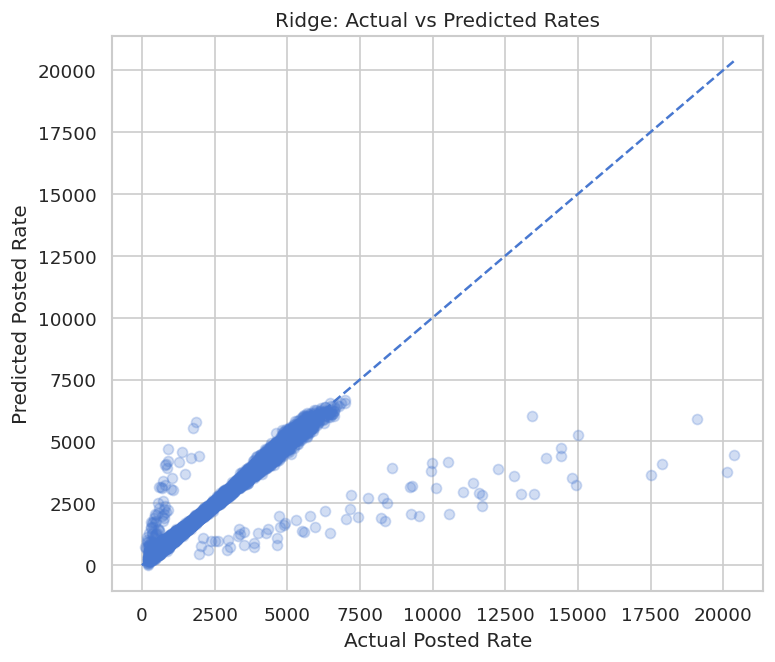

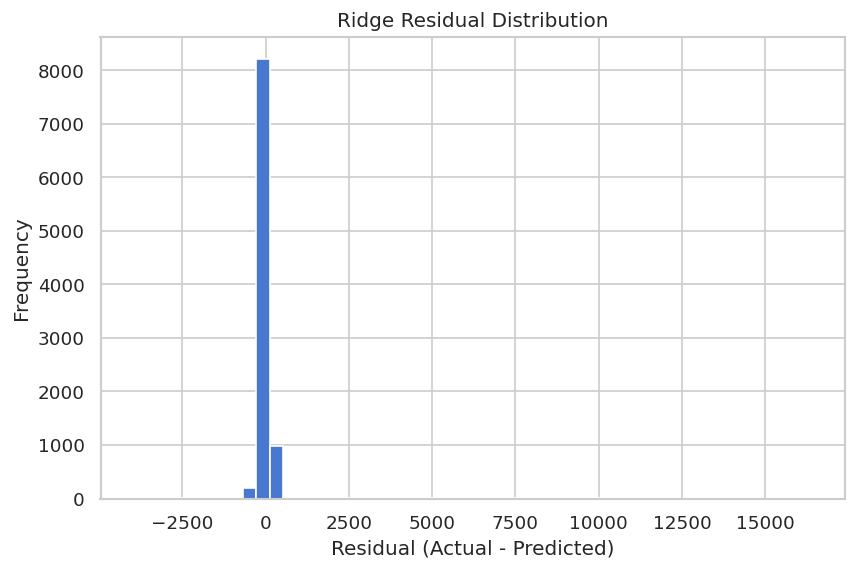

,actual_rate,predicted_rate,error
0,323.23,239.20,84.03
1,1264.20,1385.50,-121.30
2,1203.42,1122.17,81.25
3,1478.30,1428.12,50.18
4,2311.83,2237.14,74.69
5,3527.11,3713.69,-186.58
6,1052.15,1046.51,5.64
7,907.09,1049.93,-142.84
8,187.49,-7.50,194.99
9,1347.42,1252.68,94.74


In [18]:
from sklearn.linear_model import Ridge

# ---------------------------------------------------
# 1. Build final Ridge pipeline
# ---------------------------------------------------

final_ridge = Pipeline([
    ("preprocessor", clone(ridge_preprocessor)),
    ("model", Ridge(alpha=100))
])


# ---------------------------------------------------
# 2. Train on full Jan-Aug training data
# ---------------------------------------------------

final_ridge.fit(X_train, y_train)


# ---------------------------------------------------
# 3. Predict Sep-Oct validation data
# ---------------------------------------------------

ridge_val_predictions = final_ridge.predict(X_val)


# ---------------------------------------------------
# 4. Evaluation metrics
# ---------------------------------------------------

ridge_mae = mean_absolute_error(
    y_val,
    ridge_val_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ridge_val_predictions
    )
)

ridge_r2 = r2_score(
    y_val,
    ridge_val_predictions
)

print("FINAL RIDGE VALIDATION RESULTS")
print("-" * 35)
print(f"MAE:  ${ridge_mae:,.2f}")
print(f"RMSE: ${ridge_rmse:,.2f}")
print(f"R²:    {ridge_r2:.4f}")


# ---------------------------------------------------
# 5. Actual vs Predicted plot
# ---------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    ridge_val_predictions,
    alpha=0.25
)

min_value = min(
    y_val.min(),
    ridge_val_predictions.min()
)

max_value = max(
    y_val.max(),
    ridge_val_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Ridge: Actual vs Predicted Rates")
plt.xlabel("Actual Posted Rate")
plt.ylabel("Predicted Posted Rate")

plt.show()


# ---------------------------------------------------
# 6. Residual distribution
# ---------------------------------------------------

ridge_residuals = (
    y_val.values - ridge_val_predictions
)

plt.figure(figsize=(8, 5))

plt.hist(
    ridge_residuals,
    bins=50
)

plt.title("Ridge Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()


# ---------------------------------------------------
# 7. Small prediction sample
# ---------------------------------------------------

ridge_prediction_sample = pd.DataFrame({
    "actual_rate": y_val.values,
    "predicted_rate": ridge_val_predictions,
    "error": y_val.values - ridge_val_predictions
})

display(
    ridge_prediction_sample.head(15).round(2)
)

In [19]:
from xgboost import XGBRegressor
import time


# ---------------------------------------------------
# 1. Five controlled XGBoost configurations
# ---------------------------------------------------

xgb_configs = [
    {
        "config": "XGB_1",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "config": "XGB_2",
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "config": "XGB_3",
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "config": "XGB_4",
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.10,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    },
    {
        "config": "XGB_5",
        "n_estimators": 700,
        "max_depth": 4,
        "learning_rate": 0.03,
        "subsample": 0.9,
        "colsample_bytree": 0.9
    }
]


# ---------------------------------------------------
# 2. Run time-based cross-validation
# ---------------------------------------------------

xgb_results = []

for config in xgb_configs:

    print(f"\nTesting {config['config']}...")
    start_time = time.time()

    for fold in folds:

        # Expanding training data
        fold_train = train_df[
            train_df["date"] < fold["train_end"]
        ]

        # Validation month
        fold_val = train_df[
            (train_df["date"] >= fold["val_start"]) &
            (train_df["date"] < fold["val_end"])
        ]

        # Features and target
        X_fold_train = fold_train[
            categorical_features + numeric_features
        ]
        y_fold_train = fold_train[target]

        X_fold_val = fold_val[
            categorical_features + numeric_features
        ]
        y_fold_val = fold_val[target]


        # Build XGBoost pipeline
        xgb_pipeline = Pipeline([
            ("preprocessor", clone(xgb_preprocessor)),
            ("model", XGBRegressor(
                objective="reg:squarederror",

                n_estimators=config["n_estimators"],
                max_depth=config["max_depth"],
                learning_rate=config["learning_rate"],
                subsample=config["subsample"],
                colsample_bytree=config["colsample_bytree"],

                tree_method="hist",
                random_state=42,
                n_jobs=-1
            ))
        ])


        # Train
        xgb_pipeline.fit(
            X_fold_train,
            y_fold_train
        )


        # Predict
        predictions = xgb_pipeline.predict(
            X_fold_val
        )


        # Metrics
        mae = mean_absolute_error(
            y_fold_val,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                predictions
            )
        )

        r2 = r2_score(
            y_fold_val,
            predictions
        )


        xgb_results.append({
            "config": config["config"],
            "validation_month": fold["name"],
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


    elapsed = time.time() - start_time

    print(
        f"{config['config']} completed "
        f"in {elapsed:.1f} seconds"
    )


# ---------------------------------------------------
# 3. Results by fold
# ---------------------------------------------------

xgb_cv_results = pd.DataFrame(
    xgb_results
)

print("\nXGBOOST CROSS-VALIDATION RESULTS")

display(
    xgb_cv_results.round(3)
)


# ---------------------------------------------------
# 4. Average performance
# ---------------------------------------------------

xgb_cv_summary = (
    xgb_cv_results
    .groupby("config")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("\nAVERAGE PERFORMANCE BY CONFIGURATION")

display(
    xgb_cv_summary
    .sort_values("MAE")
    .round(3)
)


# ---------------------------------------------------
# 5. Show configurations for reference
# ---------------------------------------------------

display(
    pd.DataFrame(xgb_configs)
)


Testing XGB_1...
XGB_1 completed in 9.7 seconds

Testing XGB_2...
XGB_2 completed in 6.9 seconds

Testing XGB_3...
XGB_3 completed in 10.6 seconds

Testing XGB_4...
XGB_4 completed in 8.0 seconds

Testing XGB_5...
XGB_5 completed in 12.3 seconds

XGBOOST CROSS-VALIDATION RESULTS


,config,validation_month,MAE,RMSE,R2
0,XGB_1,June,174.047,735.459,0.790
1,XGB_1,July,169.574,670.681,0.801
2,XGB_1,August,162.389,666.191,0.796
3,XGB_2,June,178.257,742.375,0.786
4,XGB_2,July,177.425,680.883,0.795
5,XGB_2,August,160.100,671.764,0.793
6,XGB_3,June,171.485,741.985,0.787
7,XGB_3,July,184.087,703.074,0.782
8,XGB_3,August,166.381,698.631,0.776
9,XGB_4,June,197.574,753.299,0.780



AVERAGE PERFORMANCE BY CONFIGURATION


,config,MAE,RMSE,R2
4,XGB_5,168.636,698.937,0.791
0,XGB_1,168.670,690.777,0.796
1,XGB_2,171.927,698.341,0.791
2,XGB_3,173.984,714.563,0.781
3,XGB_4,184.807,719.398,0.778


,config,n_estimators,max_depth,learning_rate,subsample,colsample_bytree
0,XGB_1,300,4,0.05,0.9,0.9
1,XGB_2,500,3,0.05,0.9,0.9
2,XGB_3,500,5,0.05,0.9,0.9
3,XGB_4,300,5,0.10,0.9,0.9
4,XGB_5,700,4,0.03,0.9,0.9


FINAL XGBOOST VALIDATION RESULTS
-----------------------------------
MAE:  $131.92
RMSE: $660.09
R²:    0.8129


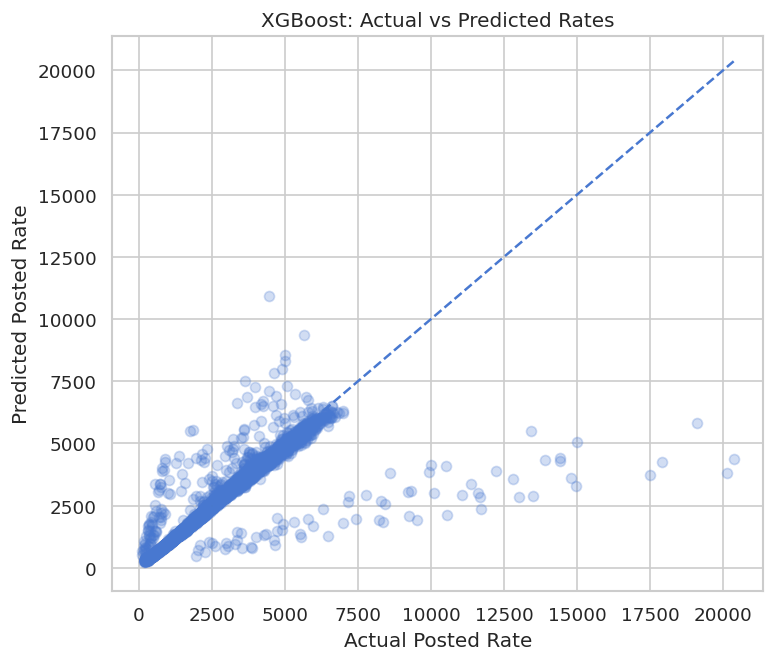

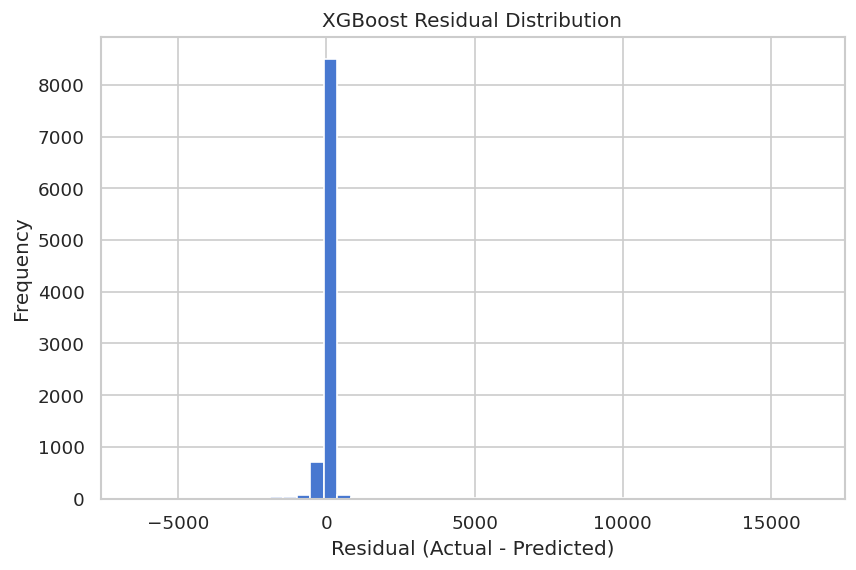


XGBoost Prediction Sample


,actual_rate,predicted_rate,error
0,323.23,311.470001,11.76
1,1264.20,1274.859985,-10.66
2,1203.42,1188.689941,14.73
3,1478.30,1465.479980,12.83
4,2311.83,2279.110107,32.72
5,3527.11,3685.300049,-158.19
6,1052.15,1020.059998,32.09
7,907.09,904.340027,2.75
8,187.49,235.630005,-48.14
9,1347.42,1327.890015,19.53



FINAL MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Ridge Regression,139.05,637.81,0.8253
1,XGBoost,131.92,660.09,0.8129


In [20]:
# ---------------------------------------------------
# 1. Build final XGBoost pipeline using XGB_1
# ---------------------------------------------------

final_xgb = Pipeline([
    ("preprocessor", clone(xgb_preprocessor)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])


# ---------------------------------------------------
# 2. Train on full Jan-Aug training data
# ---------------------------------------------------

final_xgb.fit(X_train, y_train)


# ---------------------------------------------------
# 3. Predict Sep-Oct validation data
# ---------------------------------------------------

xgb_val_predictions = final_xgb.predict(X_val)


# ---------------------------------------------------
# 4. Evaluation metrics
# ---------------------------------------------------

xgb_mae = mean_absolute_error(
    y_val,
    xgb_val_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        xgb_val_predictions
    )
)

xgb_r2 = r2_score(
    y_val,
    xgb_val_predictions
)

print("FINAL XGBOOST VALIDATION RESULTS")
print("-" * 35)
print(f"MAE:  ${xgb_mae:,.2f}")
print(f"RMSE: ${xgb_rmse:,.2f}")
print(f"R²:    {xgb_r2:.4f}")


# ---------------------------------------------------
# 5. Actual vs Predicted plot
# ---------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    xgb_val_predictions,
    alpha=0.25
)

min_value = min(
    y_val.min(),
    xgb_val_predictions.min()
)

max_value = max(
    y_val.max(),
    xgb_val_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("XGBoost: Actual vs Predicted Rates")
plt.xlabel("Actual Posted Rate")
plt.ylabel("Predicted Posted Rate")

plt.show()


# ---------------------------------------------------
# 6. Residual distribution
# ---------------------------------------------------

xgb_residuals = (
    y_val.values - xgb_val_predictions
)

plt.figure(figsize=(8, 5))

plt.hist(
    xgb_residuals,
    bins=50
)

plt.title("XGBoost Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()


# ---------------------------------------------------
# 7. Small prediction sample
# ---------------------------------------------------

xgb_prediction_sample = pd.DataFrame({
    "actual_rate": y_val.values,
    "predicted_rate": xgb_val_predictions,
    "error": y_val.values - xgb_val_predictions
})

print("\nXGBoost Prediction Sample")
display(
    xgb_prediction_sample.head(15).round(2)
)


# ---------------------------------------------------
# 8. Ridge vs XGBoost comparison
# ---------------------------------------------------

model_comparison = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "XGBoost"
    ],
    "MAE": [
        ridge_mae,
        xgb_mae
    ],
    "RMSE": [
        ridge_rmse,
        xgb_rmse
    ],
    "R2": [
        ridge_r2,
        xgb_r2
    ]
})

print("\nFINAL MODEL COMPARISON")

display(
    model_comparison.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 4
    })
)

In [21]:
ensemble_weights = [
    {"name": "75% Ridge / 25% XGB", "ridge_weight": 0.75, "xgb_weight": 0.25},
    {"name": "50% Ridge / 50% XGB", "ridge_weight": 0.50, "xgb_weight": 0.50},
    {"name": "25% Ridge / 75% XGB", "ridge_weight": 0.25, "xgb_weight": 0.75},
]

ensemble_results = []


for fold in folds:

    # ---------------------------------------------
    # 1. Create expanding train/validation fold
    # ---------------------------------------------

    fold_train = train_df[
        train_df["date"] < fold["train_end"]
    ]

    fold_val = train_df[
        (train_df["date"] >= fold["val_start"]) &
        (train_df["date"] < fold["val_end"])
    ]


    X_fold_train = fold_train[
        categorical_features + numeric_features
    ]

    y_fold_train = fold_train[target]

    X_fold_val = fold_val[
        categorical_features + numeric_features
    ]

    y_fold_val = fold_val[target]


    # ---------------------------------------------
    # 2. Ridge model
    # ---------------------------------------------

    ridge_fold_model = Pipeline([
        ("preprocessor", clone(ridge_preprocessor)),
        ("model", Ridge(alpha=100))
    ])

    ridge_fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    ridge_predictions = ridge_fold_model.predict(
        X_fold_val
    )


    # ---------------------------------------------
    # 3. XGBoost model
    # ---------------------------------------------

    xgb_fold_model = Pipeline([
        ("preprocessor", clone(xgb_preprocessor)),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ])

    xgb_fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    xgb_predictions = xgb_fold_model.predict(
        X_fold_val
    )


    # ---------------------------------------------
    # 4. Test ensemble weights
    # ---------------------------------------------

    for weights in ensemble_weights:

        ensemble_predictions = (
            weights["ridge_weight"] * ridge_predictions
            +
            weights["xgb_weight"] * xgb_predictions
        )


        mae = mean_absolute_error(
            y_fold_val,
            ensemble_predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                ensemble_predictions
            )
        )

        r2 = r2_score(
            y_fold_val,
            ensemble_predictions
        )


        ensemble_results.append({
            "ensemble": weights["name"],
            "validation_month": fold["name"],
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


# ---------------------------------------------
# 5. Results by fold
# ---------------------------------------------

ensemble_cv_results = pd.DataFrame(
    ensemble_results
)

print("ENSEMBLE CROSS-VALIDATION RESULTS")

display(
    ensemble_cv_results.round(3)
)


# ---------------------------------------------
# 6. Average results
# ---------------------------------------------

ensemble_cv_summary = (
    ensemble_cv_results
    .groupby("ensemble")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("\nAVERAGE ENSEMBLE PERFORMANCE")

display(
    ensemble_cv_summary
    .sort_values("MAE")
    .round(3)
)

ENSEMBLE CROSS-VALIDATION RESULTS


,ensemble,validation_month,MAE,RMSE,R2
0,75% Ridge / 25% XGB,June,165.055,713.068,0.803
1,50% Ridge / 50% XGB,June,160.816,716.732,0.801
2,25% Ridge / 75% XGB,June,163.306,724.235,0.797
3,75% Ridge / 25% XGB,July,167.206,639.177,0.820
4,50% Ridge / 50% XGB,July,164.537,645.081,0.816
5,25% Ridge / 75% XGB,July,165.138,655.656,0.810
6,75% Ridge / 25% XGB,August,144.447,622.849,0.822
7,50% Ridge / 50% XGB,August,146.781,631.705,0.817
8,25% Ridge / 75% XGB,August,152.734,646.277,0.808



AVERAGE ENSEMBLE PERFORMANCE


,ensemble,MAE,RMSE,R2
1,50% Ridge / 50% XGB,157.378,664.506,0.811
2,75% Ridge / 25% XGB,158.902,658.364,0.815
0,25% Ridge / 75% XGB,160.393,675.389,0.805


FINAL ENSEMBLE VALIDATION RESULTS
----------------------------------------
MAE:  $130.43
RMSE: $637.72
R²:    0.8254

FINAL MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Ridge Regression,139.05,637.81,0.8253
1,XGBoost,131.92,660.09,0.8129
2,75% Ridge + 25% XGBoost,130.43,637.72,0.8254


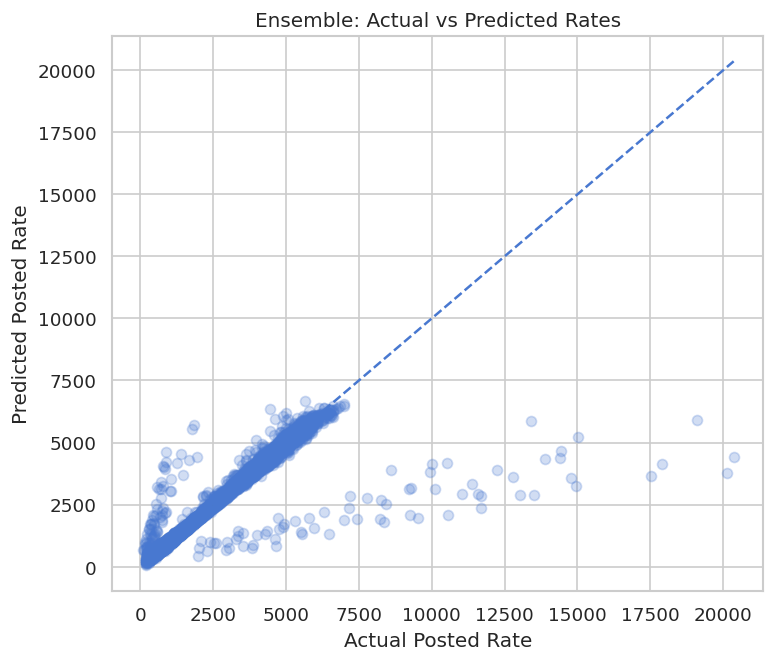

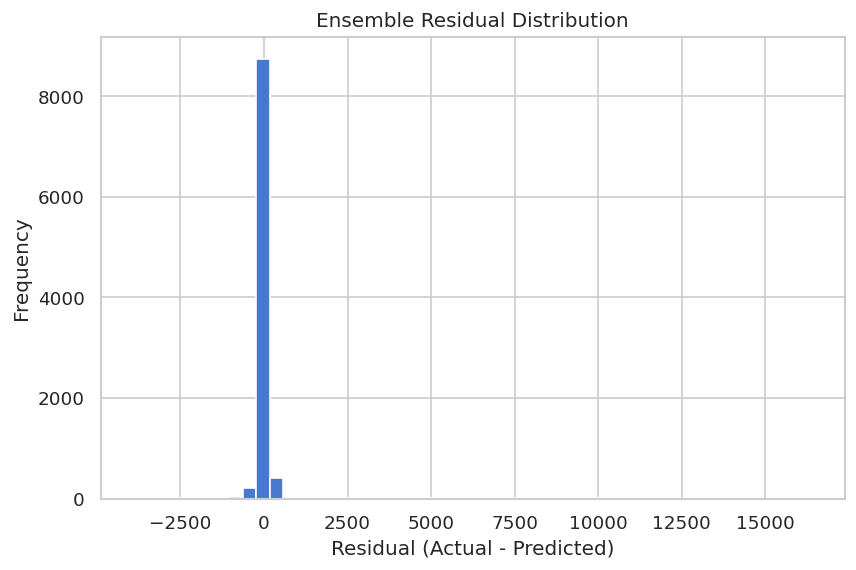


ENSEMBLE PREDICTION SAMPLE


,actual_rate,predicted_rate,error,absolute_error
0,323.23,257.27,65.96,65.96
1,1264.20,1357.84,-93.64,93.64
2,1203.42,1138.80,64.62,64.62
3,1478.30,1437.46,40.84,40.84
4,2311.83,2247.63,64.20,64.20
5,3527.11,3706.59,-179.48,179.48
6,1052.15,1039.90,12.25,12.25
7,907.09,1013.53,-106.44,106.44
8,187.49,53.28,134.21,134.21
9,1347.42,1271.48,75.94,75.94



PREDICTION VALIDITY CHECK
----------------------------------------
Minimum predicted rate: 53.28
Maximum predicted rate: 6688.21
Non-positive predictions: 0


In [22]:
# ---------------------------------------------------
# 1. Create ensemble predictions
# ---------------------------------------------------

ridge_weight = 0.75
xgb_weight = 0.25

ensemble_val_predictions = (
    ridge_weight * ridge_val_predictions
    +
    xgb_weight * xgb_val_predictions
)


# ---------------------------------------------------
# 2. Calculate evaluation metrics
# ---------------------------------------------------

ensemble_mae = mean_absolute_error(
    y_val,
    ensemble_val_predictions
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        ensemble_val_predictions
    )
)

ensemble_r2 = r2_score(
    y_val,
    ensemble_val_predictions
)


print("FINAL ENSEMBLE VALIDATION RESULTS")
print("-" * 40)
print(f"MAE:  ${ensemble_mae:,.2f}")
print(f"RMSE: ${ensemble_rmse:,.2f}")
print(f"R²:    {ensemble_r2:.4f}")


# ---------------------------------------------------
# 3. Compare all three models
# ---------------------------------------------------

final_model_comparison = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "XGBoost",
        "75% Ridge + 25% XGBoost"
    ],
    "MAE": [
        ridge_mae,
        xgb_mae,
        ensemble_mae
    ],
    "RMSE": [
        ridge_rmse,
        xgb_rmse,
        ensemble_rmse
    ],
    "R2": [
        ridge_r2,
        xgb_r2,
        ensemble_r2
    ]
})

print("\nFINAL MODEL COMPARISON")

display(
    final_model_comparison.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 4
    })
)


# ---------------------------------------------------
# 4. Actual vs Predicted
# ---------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    y_val,
    ensemble_val_predictions,
    alpha=0.25
)

min_value = min(
    y_val.min(),
    ensemble_val_predictions.min()
)

max_value = max(
    y_val.max(),
    ensemble_val_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Ensemble: Actual vs Predicted Rates")
plt.xlabel("Actual Posted Rate")
plt.ylabel("Predicted Posted Rate")

plt.show()


# ---------------------------------------------------
# 5. Residual distribution
# ---------------------------------------------------

ensemble_residuals = (
    y_val.values - ensemble_val_predictions
)

plt.figure(figsize=(8, 5))

plt.hist(
    ensemble_residuals,
    bins=50
)

plt.title("Ensemble Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()


# ---------------------------------------------------
# 6. Prediction sample
# ---------------------------------------------------

ensemble_prediction_sample = pd.DataFrame({
    "actual_rate": y_val.values,
    "predicted_rate": ensemble_val_predictions,
    "error": y_val.values - ensemble_val_predictions,
    "absolute_error": np.abs(
        y_val.values - ensemble_val_predictions
    )
})

print("\nENSEMBLE PREDICTION SAMPLE")

display(
    ensemble_prediction_sample.head(15).round(2)
)


# ---------------------------------------------------
# 7. Check prediction validity
# ---------------------------------------------------

print("\nPREDICTION VALIDITY CHECK")
print("-" * 40)

print(
    "Minimum predicted rate:",
    round(ensemble_val_predictions.min(), 2)
)

print(
    "Maximum predicted rate:",
    round(ensemble_val_predictions.max(), 2)
)

print(
    "Non-positive predictions:",
    (ensemble_val_predictions <= 0).sum()
)

EXACT ROUTE: Lexington -> Fort Wayne
--------------------------------------------------
Number of historical loads: 32
Date range: 2025-01-05 00:00:00 to 2025-10-30 00:00:00

Posted Rate Statistics


,posted_rate
count,32.00
mean,856.59
std,63.19
min,757.93
25%,796.65
50%,848.61
75%,912.59
max,973.75



Distance Statistics


,distance
count,32.00
mean,363.67
std,8.85
min,346.30
25%,358.15
50%,362.30
75%,368.15
max,384.50



Weight Statistics


...

,distance,weight,posted_rate
count,2194.00,2194.00,2194.00
mean,365.84,31866.91,862.81
std,56.99,4123.69,210.79
min,260.00,24504.00,123.32
25%,319.73,28419.25,761.40
50%,366.15,31869.00,849.76
75%,418.20,35311.50,951.65
max,460.00,39499.00,4646.65



MONTHLY EXACT-ROUTE TREND


,month,count,mean,median
0,2025-01,4,780.53,778.15
1,2025-02,2,830.74,830.74
2,2025-03,3,802.94,806.54
3,2025-04,3,827.91,848.05
4,2025-05,2,915.50,915.50
5,2025-06,1,824.39,824.39
6,2025-07,1,880.63,880.63
7,2025-08,1,796.71,796.71
8,2025-09,1,778.24,778.24
9,2025-10,3,834.17,841.42



MONTHLY SIMILAR-LOAD TREND


,month,count,mean,median
0,2025-01,240,804.63,794.87
1,2025-02,191,826.15,828.54
2,2025-03,221,859.97,837.33
3,2025-04,202,854.97,850.94
4,2025-05,215,879.26,883.20
5,2025-06,199,923.05,906.80
6,2025-07,236,861.88,845.74
7,2025-08,248,860.15,867.36
8,2025-09,206,877.20,834.96
9,2025-10,236,886.44,866.72


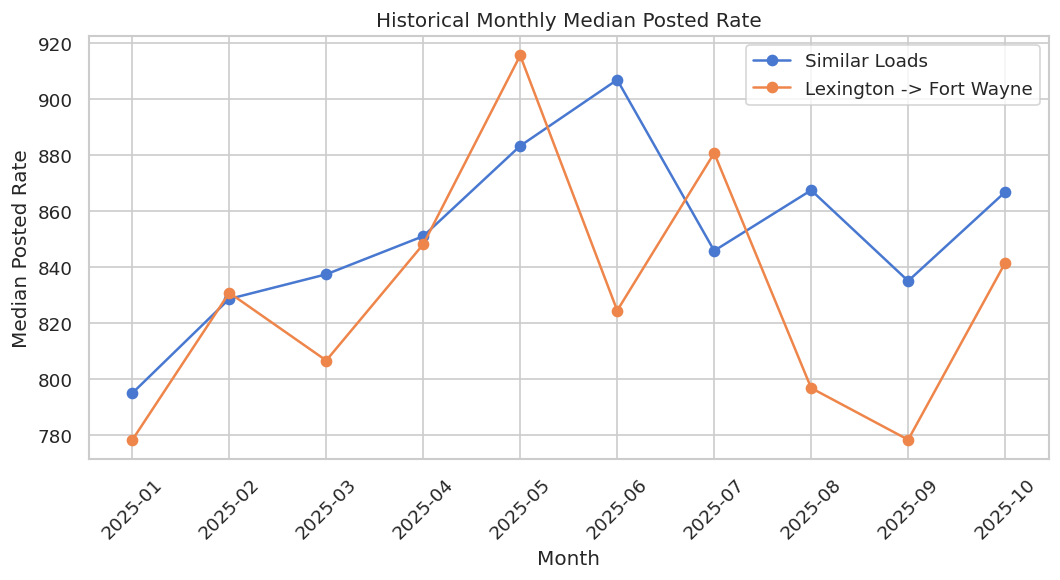


EXACT ROUTE LOADS CLOSEST TO DECEMBER INPUT


,date,distance,weight,posted_rate,distance_difference,weight_difference,similarity_score
1571,2025-01-10,358.2,31556.0,788.08,1.8,444.0,0.06
2821,2025-01-18,362.1,27842.0,768.22,2.1,4158.0,0.44
12207,2025-03-19,363.1,27600.0,810.96,3.1,4400.0,0.47
22418,2025-05-22,372.9,35578.0,896.63,12.9,3578.0,0.49
8369,2025-02-23,355.1,27601.0,791.25,4.9,4399.0,0.49
31113,2025-07-15,362.5,36951.0,880.63,2.5,4951.0,0.52
3913,2025-01-25,357.5,37102.0,807.89,2.5,5102.0,0.54
43271,2025-10-01,371.4,26829.0,841.42,11.4,5171.0,0.63
47722,2025-10-30,370.3,26358.0,864.61,10.3,5642.0,0.67
14448,2025-04-01,362.8,25383.0,786.50,2.8,6617.0,0.69


In [23]:
# ---------------------------------------------------
# December target load definition
# ---------------------------------------------------

TARGET_PICKUP = "Lexington"
TARGET_DELIVERY = "Fort Wayne"
TARGET_DISTANCE = 360
TARGET_EQUIPMENT = "Dry Van"
TARGET_WEIGHT = 32000


# ---------------------------------------------------
# 1. Exact Lexington -> Fort Wayne route
# ---------------------------------------------------

exact_route = df[
    (df["pickup"] == TARGET_PICKUP) &
    (df["delivery"] == TARGET_DELIVERY)
].copy()

print("EXACT ROUTE: Lexington -> Fort Wayne")
print("-" * 50)

print("Number of historical loads:", len(exact_route))

if len(exact_route) > 0:
    print(
        "Date range:",
        exact_route["date"].min(),
        "to",
        exact_route["date"].max()
    )

    print("\nPosted Rate Statistics")
    display(
        exact_route["posted_rate"]
        .describe()
        .to_frame("posted_rate")
        .round(2)
    )

    print("\nDistance Statistics")
    display(
        exact_route["distance"]
        .describe()
        .to_frame("distance")
        .round(2)
    )

    print("\nWeight Statistics")
    display(
        exact_route["weight"]
        .describe()
        .to_frame("weight")
        .round(2)
    )

    print("\nEquipment Distribution")
    display(
        exact_route["equipment"]
        .value_counts()
        .to_frame("count")
    )


# ---------------------------------------------------
# 2. Exact route + Dry Van only
# ---------------------------------------------------

exact_route_dryvan = exact_route[
    exact_route["equipment"] == TARGET_EQUIPMENT
].copy()

print("\nEXACT ROUTE + DRY VAN")
print("-" * 50)
print("Historical loads:", len(exact_route_dryvan))

if len(exact_route_dryvan) > 0:
    display(
        exact_route_dryvan[
            [
                "date",
                "pickup",
                "delivery",
                "distance",
                "equipment",
                "weight",
                "posted_rate"
            ]
        ]
        .sort_values("date")
        .tail(20)
    )


# ---------------------------------------------------
# 3. Similar loads
# Moderate definition:
# Dry Van
# Distance: 260-460 miles
# Weight: 24,500-39,500 lb
# ---------------------------------------------------

similar_loads = df[
    (df["equipment"] == TARGET_EQUIPMENT) &
    (df["distance"].between(260, 460)) &
    (df["weight"].between(24500, 39500))
].copy()

print("\nSIMILAR LOADS")
print("-" * 50)

print("Number of similar historical loads:", len(similar_loads))

display(
    similar_loads[
        ["distance", "weight", "posted_rate"]
    ]
    .describe()
    .round(2)
)


# ---------------------------------------------------
# 4. Monthly trend for exact route
# ---------------------------------------------------

if len(exact_route_dryvan) > 0:

    exact_route_monthly = (
        exact_route_dryvan
        .assign(month=exact_route_dryvan["date"].dt.to_period("M"))
        .groupby("month")["posted_rate"]
        .agg(["count", "mean", "median"])
        .reset_index()
    )

    print("\nMONTHLY EXACT-ROUTE TREND")

    display(
        exact_route_monthly.round(2)
    )


# ---------------------------------------------------
# 5. Monthly trend for similar loads
# ---------------------------------------------------

similar_monthly = (
    similar_loads
    .assign(month=similar_loads["date"].dt.to_period("M"))
    .groupby("month")["posted_rate"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

print("\nMONTHLY SIMILAR-LOAD TREND")

display(
    similar_monthly.round(2)
)


# ---------------------------------------------------
# 6. Plot monthly median rate trends
# ---------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    similar_monthly["month"].astype(str),
    similar_monthly["median"],
    marker="o",
    label="Similar Loads"
)

if len(exact_route_dryvan) > 0:
    plt.plot(
        exact_route_monthly["month"].astype(str),
        exact_route_monthly["median"],
        marker="o",
        label="Lexington -> Fort Wayne"
    )

plt.title("Historical Monthly Median Posted Rate")
plt.xlabel("Month")
plt.ylabel("Median Posted Rate")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 7. Exact-route loads closest to December inputs
# ---------------------------------------------------

if len(exact_route_dryvan) > 0:

    closest_exact = exact_route_dryvan.copy()

    closest_exact["distance_difference"] = (
        closest_exact["distance"] - TARGET_DISTANCE
    ).abs()

    closest_exact["weight_difference"] = (
        closest_exact["weight"] - TARGET_WEIGHT
    ).abs()

    closest_exact["similarity_score"] = (
        closest_exact["distance_difference"] / 100
        +
        closest_exact["weight_difference"] / 10000
    )

    print("\nEXACT ROUTE LOADS CLOSEST TO DECEMBER INPUT")

    display(
        closest_exact[
            [
                "date",
                "distance",
                "weight",
                "posted_rate",
                "distance_difference",
                "weight_difference",
                "similarity_score"
            ]
        ]
        .sort_values("similarity_score")
        .head(15)
        .round(2)
    )

In [24]:
# ---------------------------------------------------
# 1. Features available in december-chart-inputs.csv
# ---------------------------------------------------

dec_categorical_features = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

dec_numeric_features = [
    "distance",
    "weight",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "days_since_start"
]


# ---------------------------------------------------
# 2. December-compatible preprocessing
# ---------------------------------------------------

dec_ridge_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

dec_categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

dec_ridge_preprocessor = ColumnTransformer([
    (
        "numeric",
        dec_ridge_numeric_pipeline,
        dec_numeric_features
    ),
    (
        "categorical",
        dec_categorical_pipeline,
        dec_categorical_features
    )
])


# ---------------------------------------------------
# 3. Alpha values to test
# ---------------------------------------------------

dec_ridge_alphas = [30, 100, 300]

dec_ridge_results = []


# ---------------------------------------------------
# 4. Expanding time-based validation
# ---------------------------------------------------

for alpha in dec_ridge_alphas:

    for fold in folds:

        fold_train = train_df[
            train_df["date"] < fold["train_end"]
        ]

        fold_val = train_df[
            (train_df["date"] >= fold["val_start"]) &
            (train_df["date"] < fold["val_end"])
        ]


        X_fold_train = fold_train[
            dec_categorical_features + dec_numeric_features
        ]

        y_fold_train = fold_train[target]


        X_fold_val = fold_val[
            dec_categorical_features + dec_numeric_features
        ]

        y_fold_val = fold_val[target]


        # -------------------------------------------
        # Ridge pipeline
        # -------------------------------------------

        model = Pipeline([
            (
                "preprocessor",
                clone(dec_ridge_preprocessor)
            ),
            (
                "model",
                Ridge(alpha=alpha)
            )
        ])


        # Train
        model.fit(
            X_fold_train,
            y_fold_train
        )


        # Predict
        predictions = model.predict(
            X_fold_val
        )


        # -------------------------------------------
        # Metrics
        # -------------------------------------------

        mae = mean_absolute_error(
            y_fold_val,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                predictions
            )
        )

        r2 = r2_score(
            y_fold_val,
            predictions
        )


        dec_ridge_results.append({
            "alpha": alpha,
            "validation_month": fold["name"],
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


# ---------------------------------------------------
# 5. Results
# ---------------------------------------------------

dec_ridge_cv_results = pd.DataFrame(
    dec_ridge_results
)

print("DECEMBER-COMPATIBLE RIDGE RESULTS")

display(
    dec_ridge_cv_results.round(3)
)


# ---------------------------------------------------
# 6. Average performance by alpha
# ---------------------------------------------------

dec_ridge_summary = (
    dec_ridge_cv_results
    .groupby("alpha")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("\nAVERAGE PERFORMANCE BY ALPHA")

display(
    dec_ridge_summary.round(3)
)

DECEMBER-COMPATIBLE RIDGE RESULTS


,alpha,validation_month,MAE,RMSE,R2
0,30,June,168.942,710.281,0.805
1,30,July,212.273,647.052,0.815
2,30,August,249.978,643.878,0.809
3,100,June,170.005,710.278,0.805
4,100,July,211.877,646.166,0.816
5,100,August,249.602,642.165,0.810
6,300,June,176.934,712.414,0.803
7,300,July,213.681,647.165,0.815
8,300,August,249.417,641.665,0.811



AVERAGE PERFORMANCE BY ALPHA


,alpha,MAE,RMSE,R2
0,30,210.398,667.070,0.81
1,100,210.495,666.203,0.81
2,300,213.344,667.081,0.81


In [25]:
# ---------------------------------------------------
# 1. December-compatible XGBoost preprocessing
# ---------------------------------------------------

dec_xgb_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

dec_xgb_preprocessor = ColumnTransformer([
    (
        "numeric",
        dec_xgb_numeric_pipeline,
        dec_numeric_features
    ),
    (
        "categorical",
        dec_categorical_pipeline,
        dec_categorical_features
    )
])


# ---------------------------------------------------
# 2. Three controlled XGBoost configurations
# ---------------------------------------------------

dec_xgb_configs = [
    {
        "config": "XGB-D1",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05
    },
    {
        "config": "XGB-D2",
        "n_estimators": 500,
        "max_depth": 3,
        "learning_rate": 0.05
    },
    {
        "config": "XGB-D3",
        "n_estimators": 700,
        "max_depth": 4,
        "learning_rate": 0.03
    }
]


# ---------------------------------------------------
# 3. Time-based cross-validation
# ---------------------------------------------------

dec_xgb_results = []

for config in dec_xgb_configs:

    print(f"\nTesting {config['config']}...")

    for fold in folds:

        fold_train = train_df[
            train_df["date"] < fold["train_end"]
        ]

        fold_val = train_df[
            (train_df["date"] >= fold["val_start"]) &
            (train_df["date"] < fold["val_end"])
        ]


        # Features
        X_fold_train = fold_train[
            dec_categorical_features + dec_numeric_features
        ]

        y_fold_train = fold_train[target]

        X_fold_val = fold_val[
            dec_categorical_features + dec_numeric_features
        ]

        y_fold_val = fold_val[target]


        # -------------------------------------------
        # XGBoost pipeline
        # -------------------------------------------

        model = Pipeline([
            (
                "preprocessor",
                clone(dec_xgb_preprocessor)
            ),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",

                    n_estimators=config["n_estimators"],
                    max_depth=config["max_depth"],
                    learning_rate=config["learning_rate"],

                    subsample=0.9,
                    colsample_bytree=0.9,

                    tree_method="hist",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ])


        # Train
        model.fit(
            X_fold_train,
            y_fold_train
        )


        # Predict
        predictions = model.predict(
            X_fold_val
        )


        # -------------------------------------------
        # Metrics
        # -------------------------------------------

        mae = mean_absolute_error(
            y_fold_val,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                predictions
            )
        )

        r2 = r2_score(
            y_fold_val,
            predictions
        )


        dec_xgb_results.append({
            "config": config["config"],
            "validation_month": fold["name"],
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


# ---------------------------------------------------
# 4. Results by fold
# ---------------------------------------------------

dec_xgb_cv_results = pd.DataFrame(
    dec_xgb_results
)

print("\nDECEMBER-COMPATIBLE XGBOOST RESULTS")

display(
    dec_xgb_cv_results.round(3)
)


# ---------------------------------------------------
# 5. Average performance
# ---------------------------------------------------

dec_xgb_summary = (
    dec_xgb_cv_results
    .groupby("config")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("\nAVERAGE PERFORMANCE BY CONFIGURATION")

display(
    dec_xgb_summary
    .sort_values("MAE")
    .round(3)
)


# ---------------------------------------------------
# 6. Configuration reference
# ---------------------------------------------------

display(
    pd.DataFrame(dec_xgb_configs)
)


Testing XGB-D1...

Testing XGB-D2...

Testing XGB-D3...

DECEMBER-COMPATIBLE XGBOOST RESULTS


,config,validation_month,MAE,RMSE,R2
0,XGB-D1,June,176.334,740.026,0.788
1,XGB-D1,July,187.922,679.556,0.796
2,XGB-D1,August,177.546,668.680,0.794
3,XGB-D2,June,179.379,740.673,0.787
4,XGB-D2,July,187.090,680.555,0.795
5,XGB-D2,August,174.485,664.595,0.797
6,XGB-D3,June,176.987,740.731,0.787
7,XGB-D3,July,192.842,689.770,0.790
8,XGB-D3,August,173.540,679.262,0.788



AVERAGE PERFORMANCE BY CONFIGURATION


,config,MAE,RMSE,R2
1,XGB-D2,180.318,695.274,0.793
0,XGB-D1,180.601,696.087,0.793
2,XGB-D3,181.123,703.254,0.788


,config,n_estimators,max_depth,learning_rate
0,XGB-D1,300,4,0.05
1,XGB-D2,500,3,0.05
2,XGB-D3,700,4,0.03


In [26]:
dec_ensemble_weights = [
    {"name": "75% Ridge / 25% XGB", "ridge_weight": 0.75, "xgb_weight": 0.25},
    {"name": "50% Ridge / 50% XGB", "ridge_weight": 0.50, "xgb_weight": 0.50},
    {"name": "25% Ridge / 75% XGB", "ridge_weight": 0.25, "xgb_weight": 0.75},
]

dec_ensemble_results = []


for fold in folds:

    # ---------------------------------------------------
    # 1. Create fold
    # ---------------------------------------------------

    fold_train = train_df[
        train_df["date"] < fold["train_end"]
    ]

    fold_val = train_df[
        (train_df["date"] >= fold["val_start"]) &
        (train_df["date"] < fold["val_end"])
    ]


    X_fold_train = fold_train[
        dec_categorical_features + dec_numeric_features
    ]

    y_fold_train = fold_train[target]

    X_fold_val = fold_val[
        dec_categorical_features + dec_numeric_features
    ]

    y_fold_val = fold_val[target]


    # ---------------------------------------------------
    # 2. Ridge model
    # ---------------------------------------------------

    dec_ridge_model = Pipeline([
        (
            "preprocessor",
            clone(dec_ridge_preprocessor)
        ),
        (
            "model",
            Ridge(alpha=100)
        )
    ])

    dec_ridge_model.fit(
        X_fold_train,
        y_fold_train
    )

    ridge_predictions = dec_ridge_model.predict(
        X_fold_val
    )


    # ---------------------------------------------------
    # 3. XGBoost D2 model
    # ---------------------------------------------------

    dec_xgb_model = Pipeline([
        (
            "preprocessor",
            clone(dec_xgb_preprocessor)
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=500,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                tree_method="hist",
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    dec_xgb_model.fit(
        X_fold_train,
        y_fold_train
    )

    xgb_predictions = dec_xgb_model.predict(
        X_fold_val
    )


    # ---------------------------------------------------
    # 4. Test ensemble weights
    # ---------------------------------------------------

    for weights in dec_ensemble_weights:

        ensemble_predictions = (
            weights["ridge_weight"] * ridge_predictions
            +
            weights["xgb_weight"] * xgb_predictions
        )


        mae = mean_absolute_error(
            y_fold_val,
            ensemble_predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                ensemble_predictions
            )
        )

        r2 = r2_score(
            y_fold_val,
            ensemble_predictions
        )


        dec_ensemble_results.append({
            "ensemble": weights["name"],
            "validation_month": fold["name"],
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })


# ---------------------------------------------------
# 5. Results by fold
# ---------------------------------------------------

dec_ensemble_cv_results = pd.DataFrame(
    dec_ensemble_results
)

print("DECEMBER ENSEMBLE CROSS-VALIDATION RESULTS")

display(
    dec_ensemble_cv_results.round(3)
)


# ---------------------------------------------------
# 6. Average ensemble performance
# ---------------------------------------------------

dec_ensemble_summary = (
    dec_ensemble_cv_results
    .groupby("ensemble")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("\nAVERAGE DECEMBER ENSEMBLE PERFORMANCE")

display(
    dec_ensemble_summary
    .sort_values("MAE")
    .round(3)
)

DECEMBER ENSEMBLE CROSS-VALIDATION RESULTS


,ensemble,validation_month,MAE,RMSE,R2
0,75% Ridge / 25% XGB,June,163.037,711.771,0.804
1,50% Ridge / 50% XGB,June,162.193,717.409,0.801
2,25% Ridge / 75% XGB,June,167.604,727.096,0.795
3,75% Ridge / 25% XGB,July,203.202,646.381,0.815
4,50% Ridge / 50% XGB,July,196.176,652.308,0.812
5,25% Ridge / 75% XGB,July,190.544,663.793,0.805
6,75% Ridge / 25% XGB,August,228.677,638.540,0.813
7,50% Ridge / 50% XGB,August,208.153,641.148,0.811
8,25% Ridge / 75% XGB,August,188.837,649.914,0.806



AVERAGE DECEMBER ENSEMBLE PERFORMANCE


,ensemble,MAE,RMSE,R2
0,25% Ridge / 75% XGB,182.328,680.267,0.802
1,50% Ridge / 50% XGB,188.841,670.288,0.808
2,75% Ridge / 25% XGB,198.305,665.564,0.811


In [27]:
# Reduced feature sets
X_dec_train = train_df[dec_categorical_features + dec_numeric_features]
y_dec_train = train_df[target]

X_dec_val = val_df[dec_categorical_features + dec_numeric_features]
y_dec_val = val_df[target]


# Ridge
final_dec_ridge = Pipeline([
    ("preprocessor", clone(dec_ridge_preprocessor)),
    ("model", Ridge(alpha=100))
])

final_dec_ridge.fit(X_dec_train, y_dec_train)
dec_ridge_pred = final_dec_ridge.predict(X_dec_val)


# XGBoost
final_dec_xgb = Pipeline([
    ("preprocessor", clone(dec_xgb_preprocessor)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

final_dec_xgb.fit(X_dec_train, y_dec_train)
dec_xgb_pred = final_dec_xgb.predict(X_dec_val)


# 50/50 ensemble
dec_ensemble_pred = 0.5 * dec_ridge_pred + 0.5 * dec_xgb_pred


# Metrics
dec_mae = mean_absolute_error(y_dec_val, dec_ensemble_pred)
dec_rmse = np.sqrt(mean_squared_error(y_dec_val, dec_ensemble_pred))
dec_r2 = r2_score(y_dec_val, dec_ensemble_pred)

print("DECEMBER-COMPATIBLE MODEL — SEP/OCT HOLDOUT")
print(f"MAE:  ${dec_mae:,.2f}")
print(f"RMSE: ${dec_rmse:,.2f}")
print(f"R²:    {dec_r2:.4f}")
print("Non-positive predictions:", (dec_ensemble_pred <= 0).sum())

DECEMBER-COMPATIBLE MODEL — SEP/OCT HOLDOUT
MAE:  $147.54
RMSE: $646.66
R²:    0.8204
Non-positive predictions: 0


In [28]:
# ===================================================
# FINAL TRAINING + PREDICTION
# ===================================================

# -----------------------------
# 1. Prepare full training data
# -----------------------------

full_df = df.copy()

# Apply date features
full_df = create_date_features(full_df)

# Apply route feature
full_df = create_route_feature(full_df)


# -----------------------------
# 2. Load final datasets
# -----------------------------

validation_final = pd.read_csv("data/validation.csv")
validation_template = pd.read_csv(
    "data/validation-predictions-template.csv"
)

december_final = pd.read_csv(
    "data/december-chart-inputs.csv"
)


# -----------------------------
# 3. Apply same cleaning
# -----------------------------

# Fix negative weights if any exist
validation_final.loc[
    validation_final["weight"] < 0, "weight"
] = validation_final.loc[
    validation_final["weight"] < 0, "weight"
].abs()

december_final.loc[
    december_final["weight"] < 0, "weight"
] = december_final.loc[
    december_final["weight"] < 0, "weight"
].abs()


# -----------------------------
# 4. Feature engineering
# -----------------------------

validation_final = create_date_features(validation_final)
validation_final = create_route_feature(validation_final)

december_model_data = create_date_features(december_final)
december_model_data = create_route_feature(december_model_data)


# ===================================================
# MAIN MODEL — 12,000 VALIDATION ROWS
# 75% Ridge + 25% XGBoost
# ===================================================

X_full = full_df[
    categorical_features + numeric_features
]

y_full = full_df[target]


# Final Ridge
main_ridge = Pipeline([
    ("preprocessor", clone(ridge_preprocessor)),
    ("model", Ridge(alpha=100))
])

main_ridge.fit(X_full, y_full)


# Final XGBoost
main_xgb = Pipeline([
    ("preprocessor", clone(xgb_preprocessor)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

main_xgb.fit(X_full, y_full)


# Predict validation.csv
X_final_validation = validation_final[
    categorical_features + numeric_features
]

ridge_final_pred = main_ridge.predict(
    X_final_validation
)

xgb_final_pred = main_xgb.predict(
    X_final_validation
)

final_predictions = (
    0.75 * ridge_final_pred
    +
    0.25 * xgb_final_pred
)

# Safety check: scorer requires positive predictions
final_predictions = np.maximum(
    final_predictions,
    0.01
)


# -----------------------------
# Create submission file
# -----------------------------

prediction_lookup = pd.DataFrame({
    "load_id": validation_final["load_id"],
    "predicted_rate": final_predictions
})

validation_predictions = (
    validation_template[["load_id"]]
    .merge(
        prediction_lookup,
        on="load_id",
        how="left"
    )
)

validation_predictions.to_csv(
    "validation_predictions.csv",
    index=False
)


# ===================================================
# DECEMBER MODEL
# 50% Ridge + 50% XGBoost
# ===================================================

X_dec_full = full_df[
    dec_categorical_features + dec_numeric_features
]


# Final December Ridge
dec_ridge_final = Pipeline([
    ("preprocessor", clone(dec_ridge_preprocessor)),
    ("model", Ridge(alpha=100))
])

dec_ridge_final.fit(
    X_dec_full,
    y_full
)


# Final December XGBoost
dec_xgb_final = Pipeline([
    ("preprocessor", clone(dec_xgb_preprocessor)),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

dec_xgb_final.fit(
    X_dec_full,
    y_full
)


# December predictions
X_december = december_model_data[
    dec_categorical_features + dec_numeric_features
]

dec_ridge_predictions = dec_ridge_final.predict(
    X_december
)

dec_xgb_predictions = dec_xgb_final.predict(
    X_december
)

december_predictions = (
    0.50 * dec_ridge_predictions
    +
    0.50 * dec_xgb_predictions
)

december_predictions = np.maximum(
    december_predictions,
    0.01
)


# Put predictions back into original December file
december_output = december_final.copy()

december_output["predicted_rate"] = (
    december_predictions
)

december_output.to_csv(
    "december_predictions.csv",
    index=False
)


# -----------------------------
# Final quick checks
# -----------------------------

print("FINAL FILES CREATED")
print("-" * 40)

print(
    "validation_predictions.csv:",
    validation_predictions.shape
)

print(
    "december_predictions.csv:",
    december_output.shape
)

print(
    "\nMissing validation predictions:",
    validation_predictions["predicted_rate"]
    .isna().sum()
)

print(
    "Non-positive validation predictions:",
    (validation_predictions["predicted_rate"] <= 0)
    .sum()
)

print(
    "Non-positive December predictions:",
    (december_output["predicted_rate"] <= 0)
    .sum()
)

print("\nValidation sample:")
display(validation_predictions.head())

print("\nDecember sample:")
display(december_output.head())

FINAL FILES CREATED
----------------------------------------
validation_predictions.csv: (12000, 2)
december_predictions.csv: (31, 7)

Missing validation predictions: 0
Non-positive validation predictions: 0
Non-positive December predictions: 0

Validation sample:


,load_id,predicted_rate
0,TE-000001,912.349149
1,TE-000002,4879.048099
2,TE-000003,5485.517465
3,TE-000004,4197.518885
4,TE-000005,1879.799348



December sample:


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,846.224042
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,862.736867
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,867.178219
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,871.619572
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,870.862804


In [29]:
!python score.py \
    --predictions validation_predictions.csv \
    --december-predictions december_predictions.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
